In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
import joblib, os, json

from data_loader import load_raw

# Global style
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#333333",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "savefig.bbox": "tight",
})

PALETTE = {
    "primary":   "#2c7fb8",
    "accent":    "#e6550d",
    "success":   "#31a354",
    "danger":    "#d62728",
    "warning":   "#fec44f",
    "neutral":   "#636363",
    "purple":    "#756bb1",
}

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)
os.makedirs("../figures/preprocessing", exist_ok=True)

df = load_raw("../data/raw/frontier_2023.xlsx")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: 49,869 rows × 18 columns


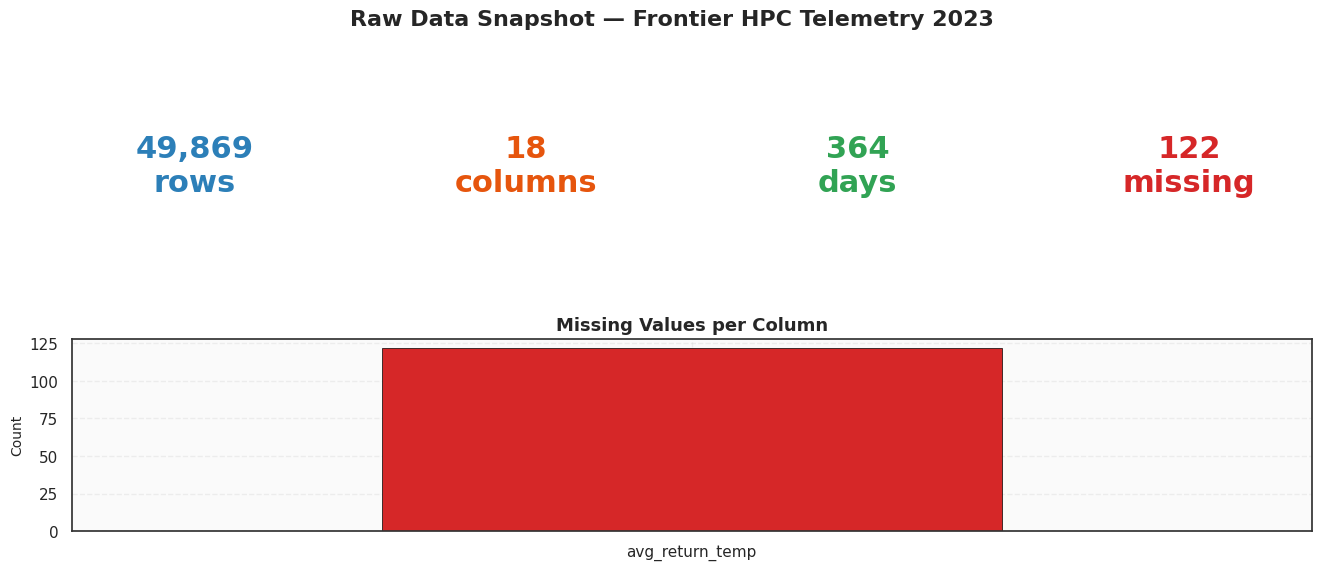

In [2]:
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.35)

# Title banner
fig.suptitle("Raw Data Snapshot — Frontier HPC Telemetry 2023",
             fontsize=16, fontweight="bold", y=0.98)

# Box 1: rows
ax = fig.add_subplot(gs[0, 0]); ax.axis("off")
ax.text(0.5, 0.5, f"{len(df):,}\nrows", ha="center", va="center",
        fontsize=22, fontweight="bold", color=PALETTE["primary"])

# Box 2: columns
ax = fig.add_subplot(gs[0, 1]); ax.axis("off")
ax.text(0.5, 0.5, f"{df.shape[1]}\ncolumns", ha="center", va="center",
        fontsize=22, fontweight="bold", color=PALETTE["accent"])

# Box 3: timespan
ax = fig.add_subplot(gs[0, 2]); ax.axis("off")
span = (df["timestamp"].max() - df["timestamp"].min()).days
ax.text(0.5, 0.5, f"{span}\ndays", ha="center", va="center",
        fontsize=22, fontweight="bold", color=PALETTE["success"])

# Box 4: total missing
ax = fig.add_subplot(gs[0, 3]); ax.axis("off")
ax.text(0.5, 0.5, f"{df.isna().sum().sum()}\nmissing", ha="center", va="center",
        fontsize=22, fontweight="bold", color=PALETTE["danger"])

# Bottom row: per-column summary bar
ax = fig.add_subplot(gs[1, :])
miss = df.isna().sum()
miss = miss[miss > 0] if (miss > 0).any() else pd.Series({"none": 0})
colors = [PALETTE["danger"]] * len(miss)
miss.plot(kind="bar", ax=ax, color=colors, edgecolor="black", linewidth=0.5)
ax.set_title("Missing Values per Column")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)

plt.savefig("../figures/preprocessing/00_raw_snapshot.png", dpi=150)
plt.show()

Columns with missing values: ['avg_return_temp']


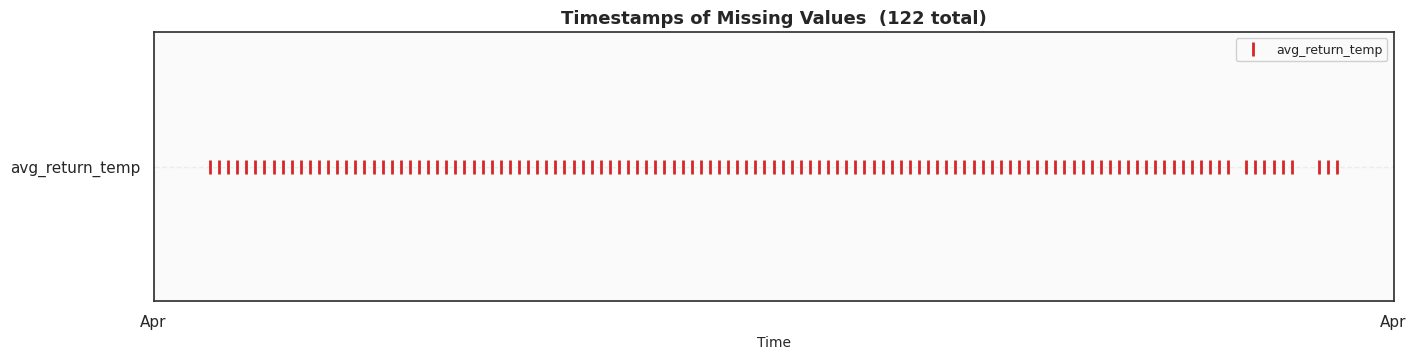

In [3]:
miss_cols = df.columns[df.isna().any()].tolist()
print("Columns with missing values:", miss_cols)

if miss_cols:
    fig, ax = plt.subplots(figsize=(16, 3.5))
    palette = [PALETTE["danger"], PALETTE["accent"], PALETTE["purple"]]

    for i, c in enumerate(miss_cols):
        missing_times = df.loc[df[c].isna(), "timestamp"]
        ax.plot(missing_times, [i] * len(missing_times), "|",
                ms=10, mew=2, color=palette[i % len(palette)], label=c)

    ax.set_yticks(range(len(miss_cols)))
    ax.set_yticklabels(miss_cols)
    ax.set_xlabel("Time")
    ax.set_title(f"Timestamps of Missing Values  ({df[miss_cols].isna().sum().sum()} total)",
                 fontsize=13, fontweight="bold")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, axis="x", alpha=0.3)

    plt.savefig("../figures/preprocessing/01_missing_map.png", dpi=150)
    plt.show()
else:
    print("No missing values — skip this plot.")

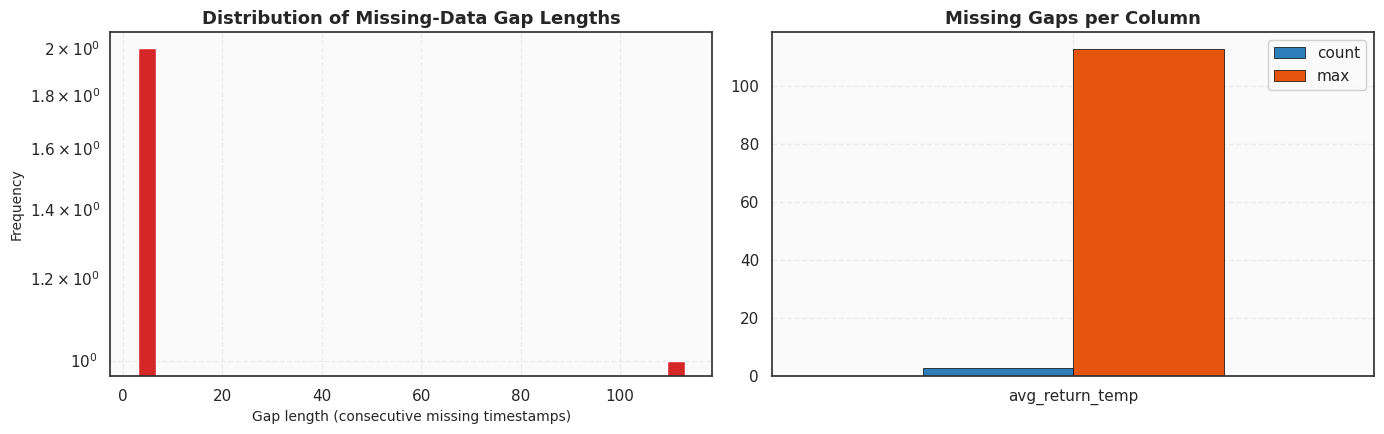

In [4]:
# Detect gap lengths for each column with missing values
gap_data = []
for c in miss_cols:
    is_na = df[c].isna()
    if not is_na.any():
        continue
    # Group consecutive True runs
    runs = (is_na != is_na.shift()).cumsum()
    lengths = is_na.groupby(runs).sum()
    lengths = lengths[lengths > 0]
    for L in lengths:
        gap_data.append({"column": c, "gap_length": L})

if gap_data:
    gap_df = pd.DataFrame(gap_data)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Histogram of gap lengths
    axes[0].hist(gap_df["gap_length"], bins=30,
                 color=PALETTE["danger"], edgecolor="white")
    axes[0].set_xlabel("Gap length (consecutive missing timestamps)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Distribution of Missing-Data Gap Lengths")
    axes[0].set_yscale("log")

    # Per-column bar
    gap_df.groupby("column")["gap_length"].agg(["count", "max"]).plot(
        kind="bar", ax=axes[1], color=[PALETTE["primary"], PALETTE["accent"]],
        edgecolor="black", linewidth=0.5)
    axes[1].set_title("Missing Gaps per Column")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig("../figures/preprocessing/02_gap_lengths.png", dpi=150)
    plt.show()
else:
    print("No gaps to analyze.")

In [5]:
full_index = pd.date_range(df["timestamp"].min(), df["timestamp"].max(),
                           freq="10min", name="timestamp")

expected_n = len(full_index)
actual_n   = len(df)
missing_n  = expected_n - actual_n

print(f"Expected grid points: {expected_n:,}")
print(f"Actual rows:          {actual_n:,}")
print(f"Missing grid points:  {missing_n:,}  ({missing_n/expected_n*100:.2f}%)")

df = df.set_index("timestamp").reindex(full_index).reset_index()
print(f"After reindex: {df.shape}")

Expected grid points: 52,560
Actual rows:          49,869
Missing grid points:  2,691  (5.12%)
After reindex: (52560, 18)


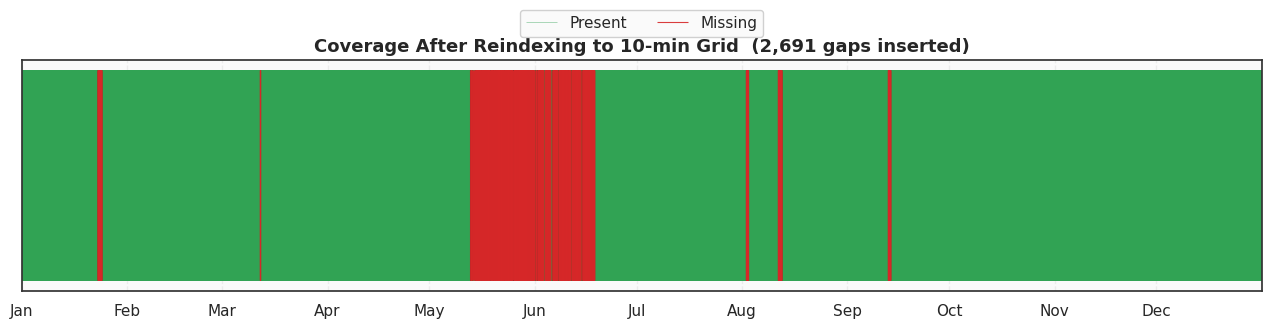

In [6]:
fig, ax = plt.subplots(figsize=(16, 3))

# Present timestamps
present_mask = ~df["pue"].isna()
present = df.loc[present_mask, "timestamp"]
missing = df.loc[~present_mask, "timestamp"]

ax.vlines(present, 0, 1, color=PALETTE["success"], lw=0.4, alpha=0.7, label="Present")
ax.vlines(missing, 0, 1, color=PALETTE["danger"], lw=0.8, alpha=0.9, label="Missing")

ax.set_yticks([])
ax.set_xlim(df["timestamp"].min(), df["timestamp"].max())
ax.set_title(f"Coverage After Reindexing to 10-min Grid  "
             f"({missing_n:,} gaps inserted)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.25))
ax.grid(True, axis="x", alpha=0.3)

plt.savefig("../figures/preprocessing/03_grid_expansion.png", dpi=150)
plt.show()

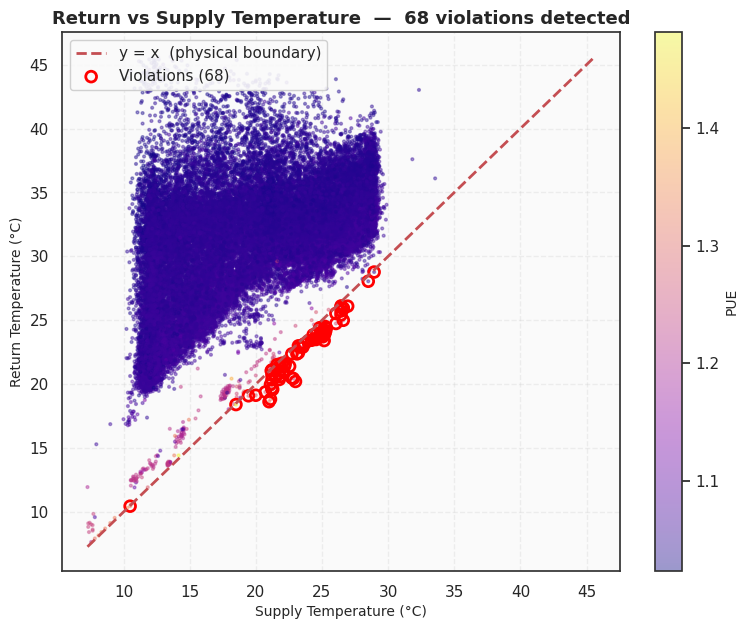

  SubLoop1 violations fixed: 348
  SubLoop2 violations fixed: 389
  SubLoop3 violations fixed: 54


In [7]:
violations_before = (df["avg_return_temp"] <= df["supply_temp"]).sum()

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(df["supply_temp"], df["avg_return_temp"],
                c=df["pue"], cmap="plasma", s=4, alpha=0.4)
lims = [np.nanmin(df[["supply_temp","avg_return_temp"]].values),
        np.nanmax(df[["supply_temp","avg_return_temp"]].values)]
ax.plot(lims, lims, "r--", lw=2, label="y = x  (physical boundary)")

# Highlight violations
mask = df["avg_return_temp"] <= df["supply_temp"]
if mask.any():
    ax.scatter(df.loc[mask, "supply_temp"], df.loc[mask, "avg_return_temp"],
               s=60, facecolors="none", edgecolors="red", linewidths=2,
               label=f"Violations ({violations_before})")

ax.set_xlabel("Supply Temperature (°C)")
ax.set_ylabel("Return Temperature (°C)")
ax.set_title(f"Return vs Supply Temperature  —  {violations_before} violations detected")
ax.legend(loc="upper left")
cb = fig.colorbar(sc, ax=ax)
cb.set_label("PUE")
plt.savefig("../figures/preprocessing/04_return_vs_supply_before.png", dpi=150)
plt.show()

# Apply fix
df.loc[mask, "avg_return_temp"] = np.nan
for i in (1, 2, 3):
    bad = df[f"s{i}_return_temp"] <= df["supply_temp"]
    df.loc[bad, f"s{i}_return_temp"] = np.nan
    print(f"  SubLoop{i} violations fixed: {bad.sum()}")

In [8]:
cols_to_interp = [c for c in df.columns if c != "timestamp"]

df = df.set_index("timestamp")
before_nan = df[cols_to_interp].isna().sum().sum()

df[cols_to_interp] = (
    df[cols_to_interp]
    .interpolate(method="time", limit=6, limit_direction="both")
)

after_nan = df[cols_to_interp].isna().sum().sum()
df = df.reset_index()

print(f"NaNs before interpolation: {before_nan:,}")
print(f"NaNs after  interpolation: {after_nan:,}")
print(f"Filled: {before_nan - after_nan:,}")
print("\nRemaining NaNs per column:")
print(df.isna().sum()[df.isna().sum() > 0])

NaNs before interpolation: 59,648
NaNs after  interpolation: 45,052
Filled: 14,596

Remaining NaNs per column:
s1_return_temp     2759
s1_flow            2626
s2_return_temp     2769
s2_flow            2626
s3_return_temp     2640
s3_flow            2626
avg_return_temp    2746
supply_temp        2626
total_flow         2626
s1_heat            2626
s2_heat            2626
s3_heat            2626
total_heat         2626
compute_power      2626
accessory_power    2626
total_power        2626
pue                2626
dtype: int64


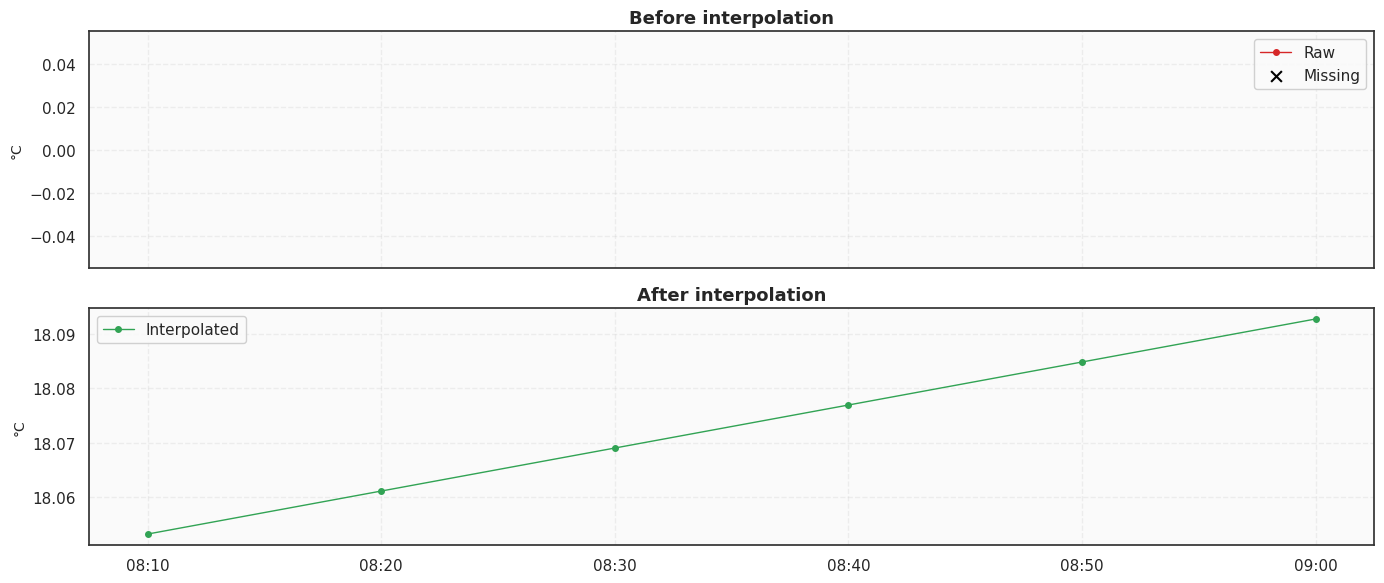

In [9]:
# Reload raw to compare (make sure it exists)
raw = load_raw("../data/raw/frontier_2023.xlsx")

col = "avg_return_temp"
zoom_start = raw.loc[raw[col].isna(), "timestamp"].min()
if pd.isna(zoom_start):
    zoom_start = raw["timestamp"].min()
zoom_end = zoom_start + pd.Timedelta(hours=6)

raw_zoom = raw[(raw["timestamp"] >= zoom_start) & (raw["timestamp"] <= zoom_end)]
clean_zoom = df[(df["timestamp"] >= zoom_start) & (df["timestamp"] <= zoom_end)]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(raw_zoom["timestamp"], raw_zoom[col],
             marker="o", ms=4, lw=1, color=PALETTE["danger"], label="Raw")
axes[0].scatter(raw_zoom.loc[raw_zoom[col].isna(), "timestamp"],
                np.full(raw_zoom[col].isna().sum(), raw_zoom[col].min()),
                marker="x", s=60, color="black", label="Missing")
axes[0].set_ylabel("°C"); axes[0].set_title("Before interpolation")
axes[0].legend()

axes[1].plot(clean_zoom["timestamp"], clean_zoom[col],
             marker="o", ms=4, lw=1, color=PALETTE["success"], label="Interpolated")
axes[1].set_ylabel("°C"); axes[1].set_title("After interpolation")
axes[1].legend()

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.savefig("../figures/preprocessing/05_interpolation.png", dpi=150)
plt.show()

Dropped 2542 rows
Final shape: (50018, 18)


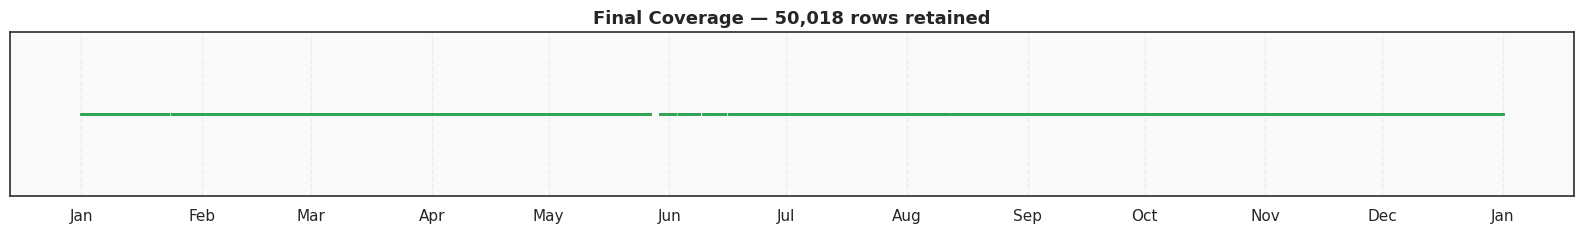

In [10]:
df = df.ffill(limit=3).bfill(limit=3)

before = len(df)
df = df.dropna().reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after} rows")
print("Final shape:", df.shape)

# Coverage ribbon
fig, ax = plt.subplots(figsize=(16, 2.5))
ax.plot(df["timestamp"], np.ones(len(df)), "|", ms=1.5, color=PALETTE["success"])
ax.set_yticks([]); ax.set_ylim(0, 2)
ax.set_title(f"Final Coverage — {len(df):,} rows retained")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
plt.savefig("../figures/preprocessing/06_coverage_final.png", dpi=150)
plt.show()

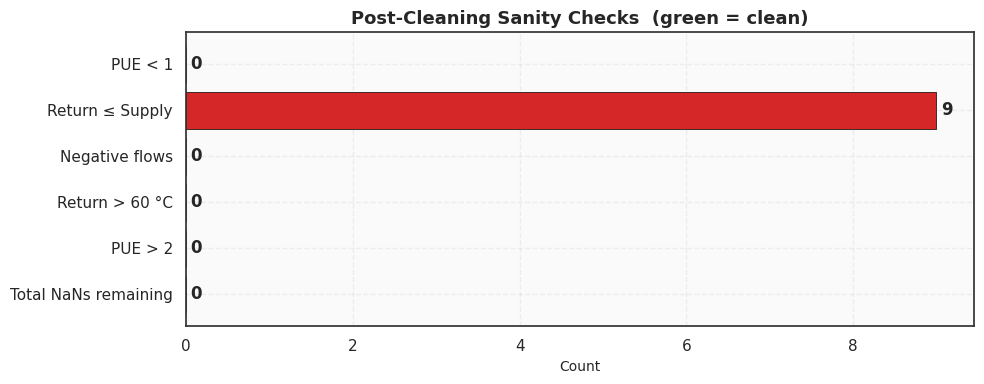

In [11]:
checks = {
    "PUE < 1":             (df["pue"] < 1).sum(),
    "Return ≤ Supply":     (df["avg_return_temp"] <= df["supply_temp"]).sum(),
    "Negative flows":      (df[["s1_flow","s2_flow","s3_flow","total_flow"]] < 0).any(axis=1).sum(),
    "Return > 60 °C":      (df["avg_return_temp"] > 60).sum(),
    "PUE > 2":             (df["pue"] > 2).sum(),
    "Total NaNs remaining": df.isna().sum().sum(),
}

fig, ax = plt.subplots(figsize=(10, 4))
names = list(checks.keys())
vals  = list(checks.values())
colors = [PALETTE["success"] if v == 0 else PALETTE["danger"] for v in vals]
bars = ax.barh(names, vals, color=colors, edgecolor="black", linewidth=0.5)

for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{v}", va="center", fontweight="bold")

ax.set_xlabel("Count")
ax.set_title("Post-Cleaning Sanity Checks  (green = clean)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/preprocessing/07_sanity_checks.png", dpi=150)
plt.show()

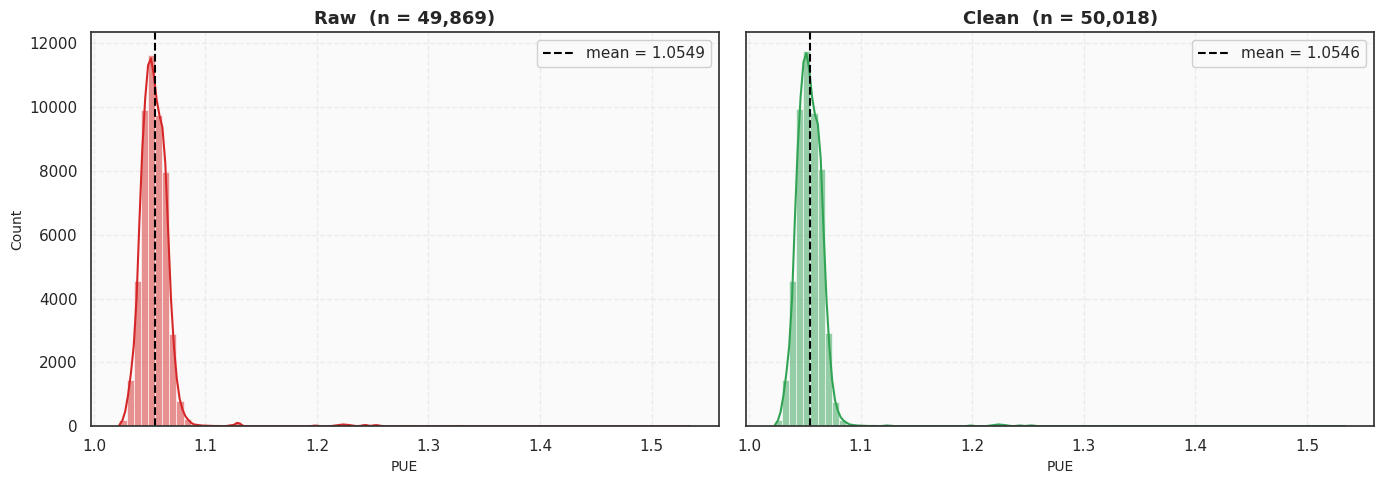

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(raw["pue"].dropna(), bins=80, kde=True,
             color=PALETTE["danger"], ax=axes[0], edgecolor="white")
axes[0].axvline(raw["pue"].mean(), color="black", ls="--", lw=1.5,
                label=f"mean = {raw['pue'].mean():.4f}")
axes[0].set_title(f"Raw  (n = {len(raw):,})")
axes[0].set_xlabel("PUE"); axes[0].legend()

sns.histplot(df["pue"], bins=80, kde=True,
             color=PALETTE["success"], ax=axes[1], edgecolor="white")
axes[1].axvline(df["pue"].mean(), color="black", ls="--", lw=1.5,
                label=f"mean = {df['pue'].mean():.4f}")
axes[1].set_title(f"Clean  (n = {len(df):,})")
axes[1].set_xlabel("PUE"); axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/preprocessing/08_pue_before_after.png", dpi=150)
plt.show()

In [13]:
df = df.copy()

# Time features
df["hour"]     = df["timestamp"].dt.hour
df["dow"]      = df["timestamp"].dt.dayofweek
df["month"]    = df["timestamp"].dt.month
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df["dow"]  / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df["dow"]  / 7)

# Physics-derived
df["temp_lift"]       = df["avg_return_temp"] - df["supply_temp"]
df["heat_per_flow"]   = df["total_heat"] / (df["total_flow"] + 1e-6)
df["accessory_ratio"] = df["accessory_power"] / (df["total_power"] + 1e-6)
df["flow_imbalance"]  = df[["s1_flow","s2_flow","s3_flow"]].std(axis=1)
df["temp_imbalance"]  = df[["s1_return_temp","s2_return_temp","s3_return_temp"]].std(axis=1)

# Lag features
for col in ["avg_return_temp", "pue", "compute_power", "accessory_power"]:
    for lag in (1, 3, 6):
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

# Rolling means
for col in ["avg_return_temp", "pue", "compute_power"]:
    df[f"{col}_roll3"] = df[col].rolling(3).mean()
    df[f"{col}_roll6"] = df[col].rolling(6).mean()

before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {before - len(df)} rows due to lag/rolling NaNs")
print("Final shape:", df.shape)

Dropped 6 rows due to lag/rolling NaNs
Final shape: (50012, 48)


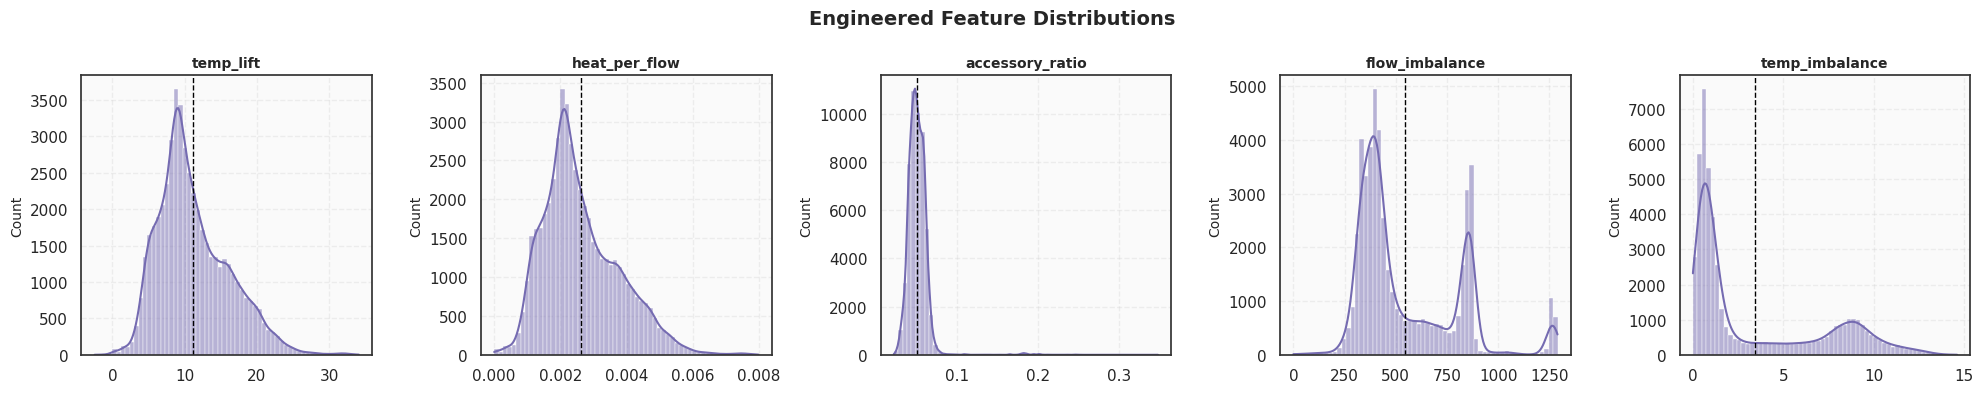

In [14]:
engineered = ["temp_lift", "heat_per_flow", "accessory_ratio",
              "flow_imbalance", "temp_imbalance"]

fig, axes = plt.subplots(1, len(engineered), figsize=(20, 4))

for ax, c in zip(axes, engineered):
    sns.histplot(df[c].dropna(), bins=60, kde=True,
                 color=PALETTE["purple"], ax=ax, edgecolor="white")
    ax.set_title(c, fontsize=10)
    ax.set_xlabel("")
    ax.axvline(df[c].mean(), color="black", ls="--", lw=1)

plt.suptitle("Engineered Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/preprocessing/09_engineered_features.png", dpi=150)
plt.show()

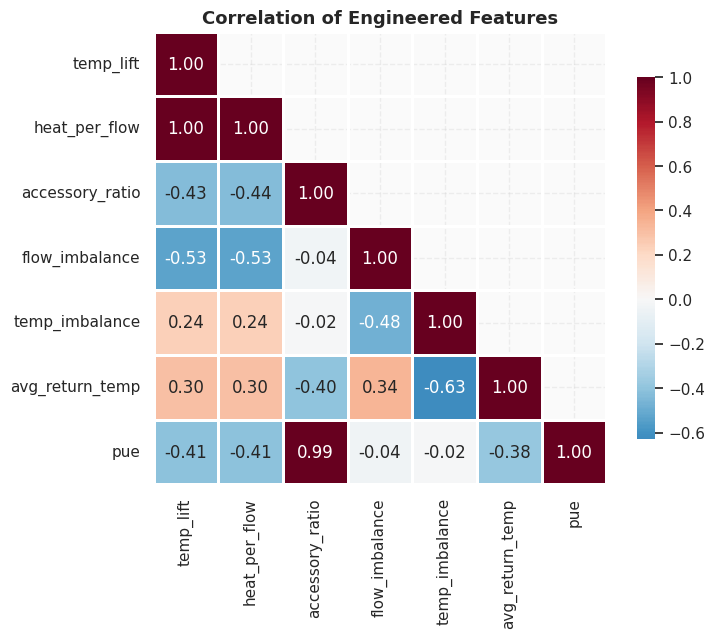

In [15]:
eng_df = df[["temp_lift", "heat_per_flow", "accessory_ratio",
             "flow_imbalance", "temp_imbalance",
             "avg_return_temp", "pue"]]
corr = eng_df.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=1, linecolor="white",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation of Engineered Features")
plt.tight_layout()
plt.savefig("../figures/preprocessing/10_engineered_corr.png", dpi=150)
plt.show()

In [16]:
feature_cols = [
    "compute_power", "accessory_power", "supply_temp", "total_flow",
    "s1_flow", "s2_flow", "s3_flow",
    "s1_return_temp", "s2_return_temp", "s3_return_temp",
    "total_heat", "s1_heat", "s2_heat", "s3_heat",
    "temp_lift", "heat_per_flow", "accessory_ratio",
    "flow_imbalance", "temp_imbalance",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "avg_return_temp_lag1", "avg_return_temp_lag3", "avg_return_temp_lag6",
    "pue_lag1", "pue_lag3", "pue_lag6",
    "compute_power_lag1", "compute_power_lag3",
    "accessory_power_lag1", "accessory_power_lag3",
    "avg_return_temp_roll3", "avg_return_temp_roll6",
    "pue_roll3", "pue_roll6",
    "compute_power_roll3", "compute_power_roll6",
]
target_col = "avg_return_temp"

missing = [c for c in feature_cols if c not in df.columns]
print("Missing features:", missing)
print(f"Selected: {len(feature_cols)} features, target = {target_col}")

Missing features: []
Selected: 39 features, target = avg_return_temp


Train: 35,008  | Val: 7,502  | Test: 7,502


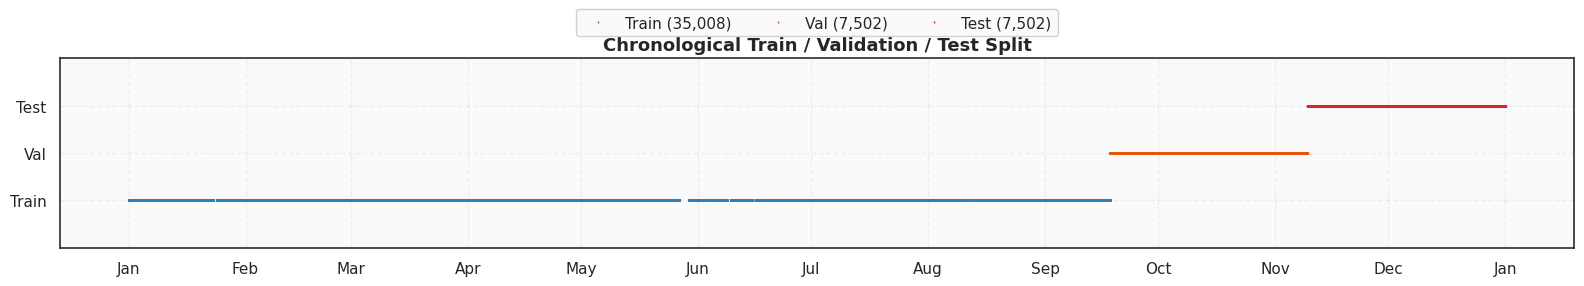

In [17]:
n = len(df)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train = df.iloc[:train_end].copy()
val   = df.iloc[train_end:val_end].copy()
test  = df.iloc[val_end:].copy()

print(f"Train: {len(train):,}  | Val: {len(val):,}  | Test: {len(test):,}")

fig, ax = plt.subplots(figsize=(16, 3.2))
ax.plot(train["timestamp"], np.ones(len(train)),  "|", ms=2, color=PALETTE["primary"], label=f"Train ({len(train):,})")
ax.plot(val["timestamp"],   np.ones(len(val))*1.1, "|", ms=2, color=PALETTE["accent"],  label=f"Val ({len(val):,})")
ax.plot(test["timestamp"],  np.ones(len(test))*1.2,"|", ms=2, color=PALETTE["danger"],  label=f"Test ({len(test):,})")

ax.set_yticks([1.0, 1.1, 1.2])
ax.set_yticklabels(["Train", "Val", "Test"])
ax.set_ylim(0.9, 1.3)
ax.set_title("Chronological Train / Validation / Test Split")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.3))
plt.tight_layout()
plt.savefig("../figures/preprocessing/11_split.png", dpi=150)
plt.show()

Scaling complete.


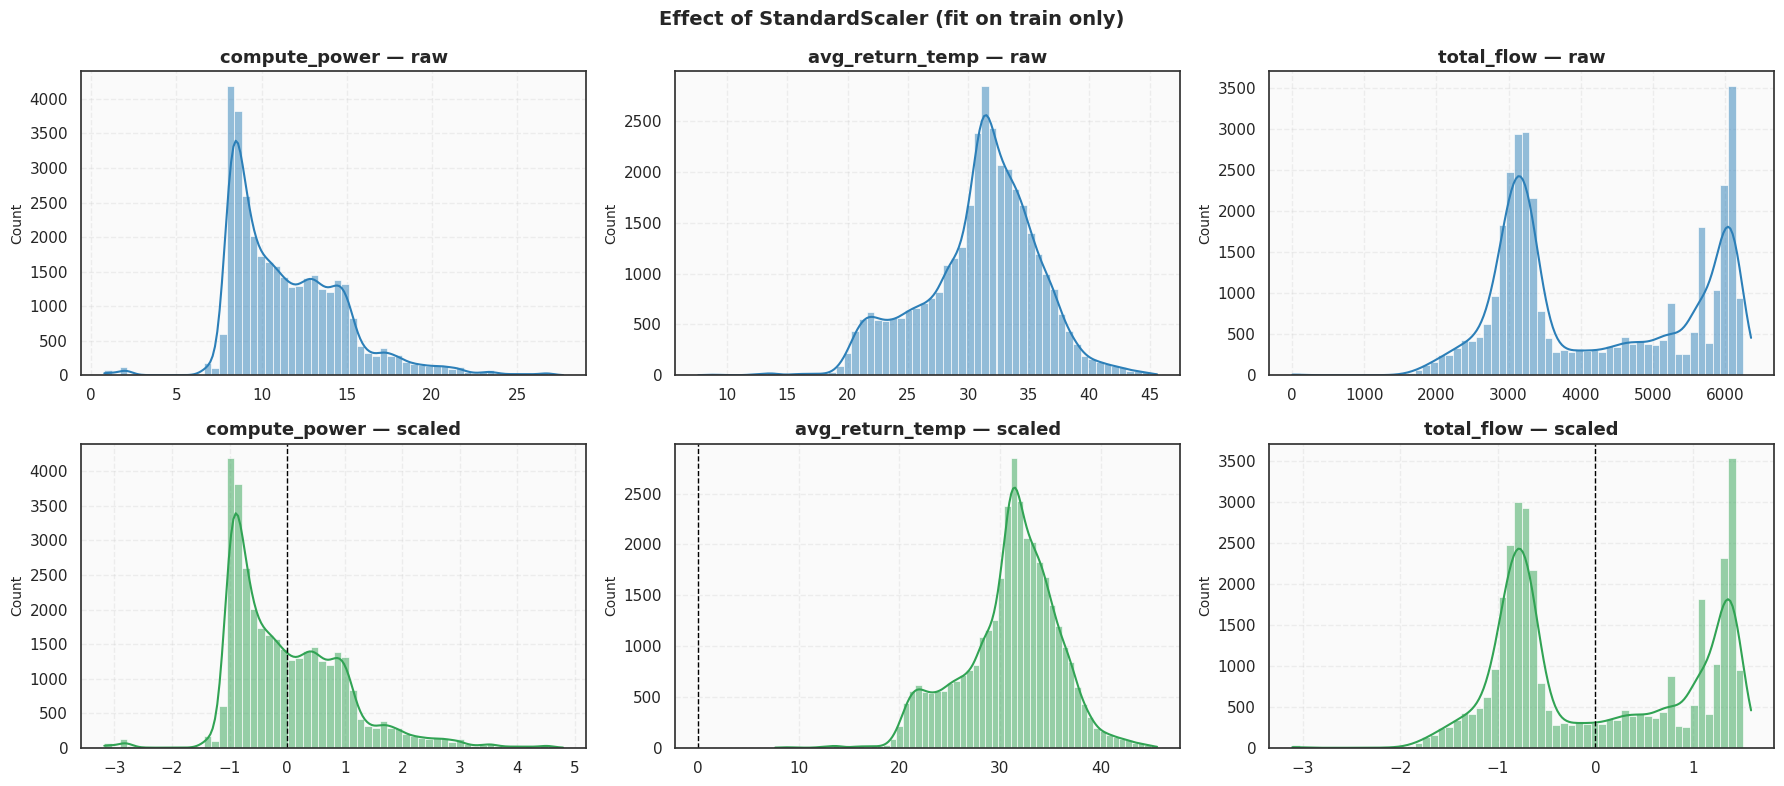

In [18]:
scaler = StandardScaler().fit(train[feature_cols])

train_scaled = train.copy()
val_scaled   = val.copy()
test_scaled  = test.copy()

train_scaled[feature_cols] = scaler.transform(train[feature_cols])
val_scaled[feature_cols]   = scaler.transform(val[feature_cols])
test_scaled[feature_cols]  = scaler.transform(test[feature_cols])

print("Scaling complete.")

sample_feats = ["compute_power", "avg_return_temp", "total_flow"]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, c in enumerate(sample_feats):
    sns.histplot(train[c], bins=60, kde=True, ax=axes[0, i],
                 color=PALETTE["primary"], edgecolor="white")
    axes[0, i].set_title(f"{c} — raw")
    axes[0, i].set_xlabel("")

    sns.histplot(train_scaled[c], bins=60, kde=True, ax=axes[1, i],
                 color=PALETTE["success"], edgecolor="white")
    axes[1, i].set_title(f"{c} — scaled")
    axes[1, i].set_xlabel("")
    axes[1, i].axvline(0, color="black", ls="--", lw=1)

plt.suptitle("Effect of StandardScaler (fit on train only)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/preprocessing/12_scaling.png", dpi=150)
plt.show()

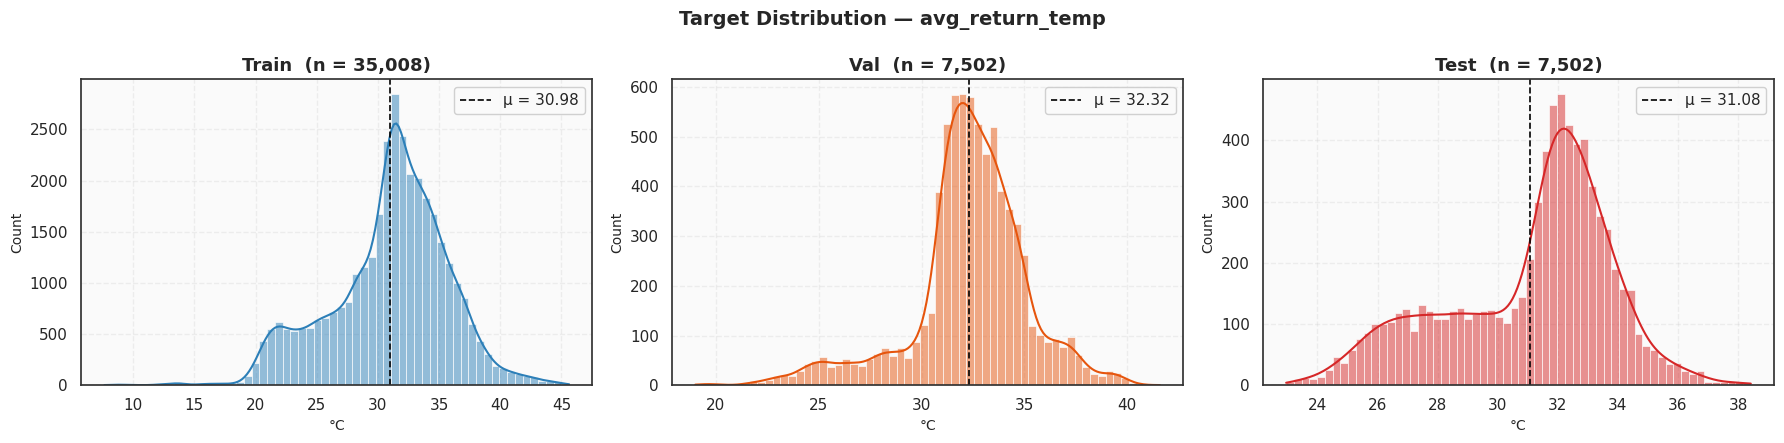

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, (name, split, color) in zip(
        axes,
        [("Train", train, PALETTE["primary"]),
         ("Val",   val,   PALETTE["accent"]),
         ("Test",  test,  PALETTE["danger"])]):
    sns.histplot(split[target_col], bins=60, kde=True,
                 color=color, ax=ax, edgecolor="white")
    mu = split[target_col].mean()
    ax.axvline(mu, color="black", ls="--", lw=1.2, label=f"μ = {mu:.2f}")
    ax.set_title(f"{name}  (n = {len(split):,})")
    ax.set_xlabel("°C"); ax.legend()

plt.suptitle(f"Target Distribution — {target_col}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/preprocessing/13_target_distribution.png", dpi=150)
plt.show()

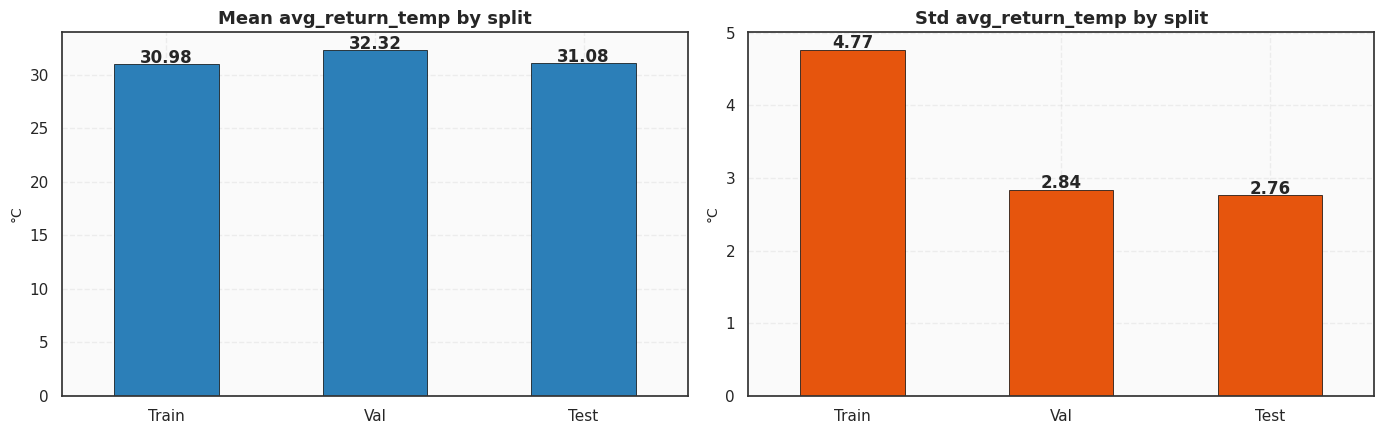

         mean    std
Train  30.981  4.767
Val    32.324  2.838
Test   31.081  2.760


In [20]:
stats_df = pd.DataFrame({
    "Train": [train[target_col].mean(), train[target_col].std()],
    "Val":   [val[target_col].mean(),   val[target_col].std()],
    "Test":  [test[target_col].mean(),  test[target_col].std()],
}, index=["mean", "std"]).T

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

stats_df["mean"].plot(kind="bar", ax=axes[0], color=PALETTE["primary"],
                      edgecolor="black", linewidth=0.5)
axes[0].set_title(f"Mean {target_col} by split")
axes[0].set_ylabel("°C")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(stats_df["mean"]):
    axes[0].text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")

stats_df["std"].plot(kind="bar", ax=axes[1], color=PALETTE["accent"],
                     edgecolor="black", linewidth=0.5)
axes[1].set_title(f"Std {target_col} by split")
axes[1].set_ylabel("°C")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(stats_df["std"]):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../figures/preprocessing/14_split_stats.png", dpi=150)
plt.show()

print(stats_df.round(3))

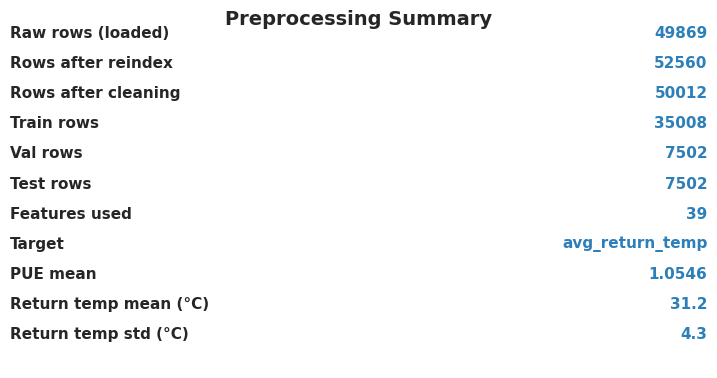

Raw rows (loaded)            49869
Rows after reindex           52560
Rows after cleaning          50012
Train rows                   35008
Val rows                     7502
Test rows                    7502
Features used                39
Target                       avg_return_temp
PUE mean                     1.0546
Return temp mean (°C)        31.2
Return temp std (°C)         4.3


In [25]:
summary = {
    "Raw rows (loaded)": 49869,
    "Rows after reindex": len(full_index),
    "Rows after cleaning": len(df),
    "Train rows": len(train),
    "Val rows": len(val),
    "Test rows": len(test),
    "Features used": len(feature_cols),
    "Target": target_col,
    "PUE mean": round(df["pue"].mean(), 4),
    "Return temp mean (°C)": round(df["avg_return_temp"].mean(), 2),
    "Return temp std (°C)": round(df["avg_return_temp"].std(), 2),
}

fig, ax = plt.subplots(figsize=(9, 0.5 + 0.35 * len(summary)))
ax.axis("off")

y = 1.0
for k, v in summary.items():
    ax.text(0.0, y, k, fontsize=11, fontweight="bold", va="center")
    ax.text(1.0, y, str(v), fontsize=11, ha="right", va="center",
            color=PALETTE["primary"], fontweight="bold")
    y -= 0.09

ax.set_title("Preprocessing Summary", fontsize=14, fontweight="bold")
plt.savefig("../figures/preprocessing/15_summary.png", dpi=150)
plt.show()

for k, v in summary.items():
    print(f"{k:28s} {v}")